f(x) = 0.2548x² + -4.8060x + 90.4146
Predicted speed at 17:00: 82.34


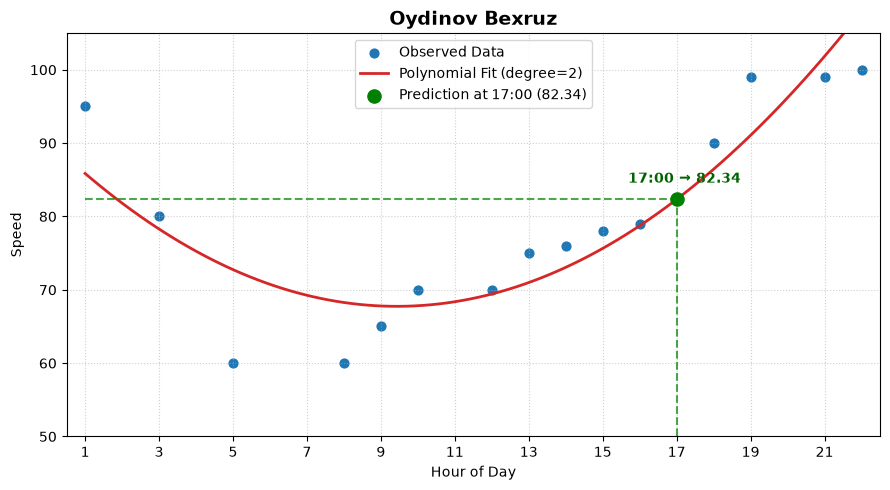

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Data (x: hour of day, y: speed)
x = [1, 3, 5, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 21, 22]
y = [95, 80, 60, 60, 65, 70, 70, 75, 76, 78, 79, 90, 99, 99, 100]

# Create a regression model using a second-degree polynomial
mymodel = np.poly1d(np.polyfit(x, y, 2))

# Extract the coefficients: f(x) = ax^2 + bx + c
a, b, c = mymodel.coefficients

# Prediction function
def f(x_value):
    return mymodel(x_value)

# Print the prediction equation
print(f"f(x) = {a:.4f}x² + {b:.4f}x + {c:.4f}")

# Target time: 5:00 PM (17:00)
target_time = 17
predicted_speed = f(target_time)

# 1. Print the predicted speed
print(f"Predicted speed at 17:00: {predicted_speed:.2f}")

# Generate x-values for smooth curve rendering
myline = np.linspace(1, 22, 100)

# Visualization setup
plt.figure(figsize=(9, 5))
plt.scatter(x, y, color="#1f77b4", label="Observed Data", s=40)
plt.plot(myline, f(myline), color="#d62728", lw=2, label="Polynomial Fit (degree=2)")

# 2. Display prediction point and dashed projection lines to axes
plt.vlines(x=target_time, ymin=50, ymax=predicted_speed, colors="green", linestyles="--", alpha=0.7)
plt.hlines(y=predicted_speed, xmin=1, xmax=target_time, colors="green", linestyles="--", alpha=0.7)

plt.scatter(target_time, predicted_speed, color="green", s=90, zorder=5, label=f"Prediction at 17:00 ({predicted_speed:.2f})")
plt.annotate(
    f"17:00 → {predicted_speed:.2f}",
    (target_time, predicted_speed),
    textcoords="offset points",
    xytext=(-35, 12),
    fontweight="bold",
    color="darkgreen"
)

# Insert 17 cleanly onto the x-axis (odd-hour intervals align with 17 without overlap)
plt.xticks(list(range(1, 23, 2)))
plt.xlim(0.5, 22.5)
plt.ylim(50, 105)

# Graph styling
plt.title("Oydinov Bexruz", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Speed")
plt.legend(loc="upper center")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()